<a href="https://colab.research.google.com/github/RiazullJannat/ML/blob/main/ML_mid_term_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 1: Exploratory Data Analysis (EDA) -20

Problem Statement:
Find the three most important factors that separate individuals who earn more than $50K annually from those who earn $50K or less.
Tasks:
1. Perform EDA using appropriate charts and basic descriptive statistics.
2. Select your top 3 features and justify your choices using visual and statistical evidence.
3. For each selected feature, explain in simple terms why it intuitively affects income.
Rank your 3 features from most important to least important, provide why you think that ?


In [157]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [158]:
# reading df
df = pd.read_csv("./sample_data/adult_income.csv")
df.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
20469,30,Private,390879,Assoc-voc,11,Divorced,Prof-specialty,Unmarried,White,Female,0,0,36,United-States,<=50K
38955,38,Private,193945,HS-grad,9,Never-married,Transport-moving,Not-in-family,White,Male,0,0,40,United-States,<=50K.
46423,53,Self-emp-not-inc,263439,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States,>50K.
45742,56,Self-emp-not-inc,121362,Bachelors,13,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K.
19315,23,Private,377121,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,25,United-States,<=50K


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


## Clean and Prepare Data

### Subtask:
Clean the 'income' column to ensure consistent labels (e.g., '>50K' and '<=50K') by removing any extra characters like periods. Also, identify and separate categorical and numerical features for appropriate analysis.


In [160]:
df['income'].unique()
df['income'] = df['income'].str.replace('.','', regex=False).str.strip()
df['income'].unique()


array(['<=50K', '>50K'], dtype=object)

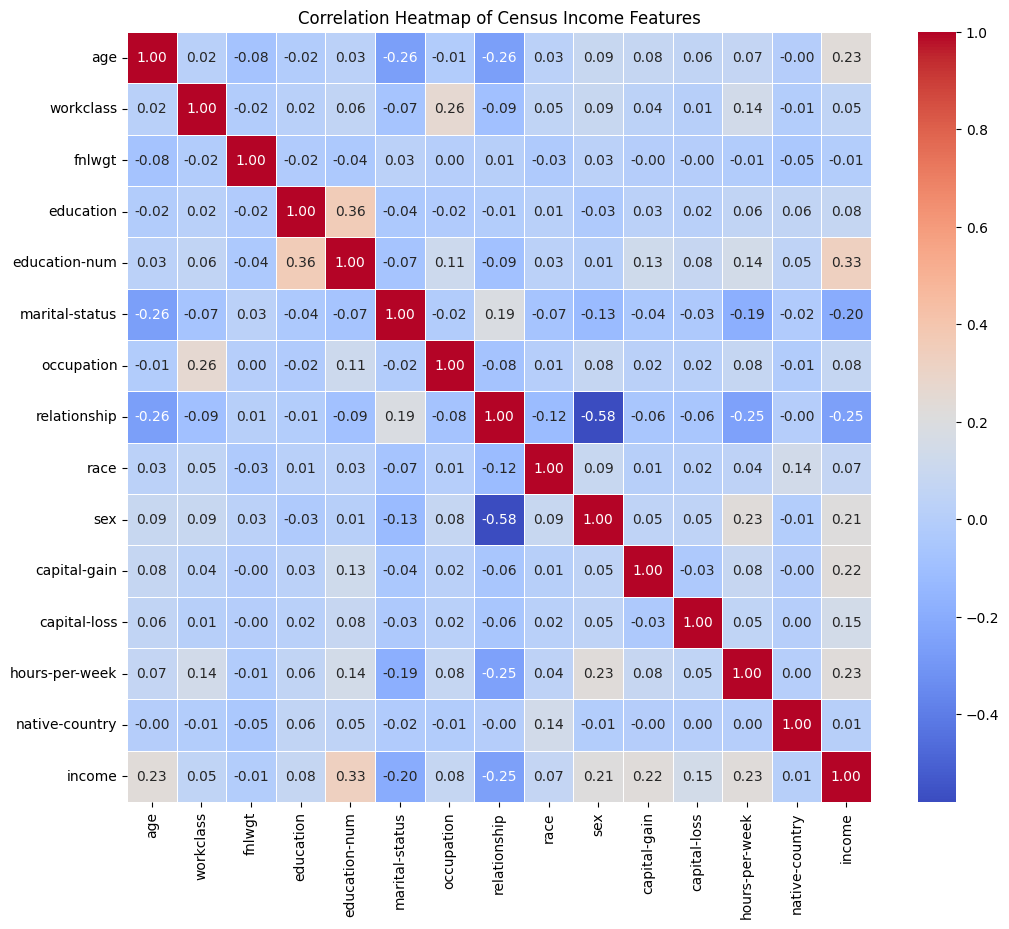

In [161]:
le = LabelEncoder()
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

correlation_matrix = df_encoded.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Census Income Features')
plt.show()

In [168]:
income_impact = correlation_matrix['income'].drop('income').abs()
priority_list = income_impact.sort_values(ascending=False).reset_index()
priority_list.columns = ['Feature_Name', 'Correlation_Strength']
print("Top 3 Feature List:-> \n",priority_list[:3])

Top 3 Feature List:-> 
     Feature_Name  Correlation_Strength
0  education-num              0.332613
1   relationship              0.253214
2            age              0.230369


# **Selected 3 features that are direct effecting income range.**

#### Why it matters:
So, `education-num` (which is basically years of education) is the *most* important feature here, looking at our correlation list. Makes sense, right? If you check out the boxplot we made for 'Years of Education vs. Income', you can clearly see that people with more years of education tend to land in that '>50K' income bracket. It's like, the more you learn, the more opportunities open up, and usually, that means better-paying jobs. Simple as that!

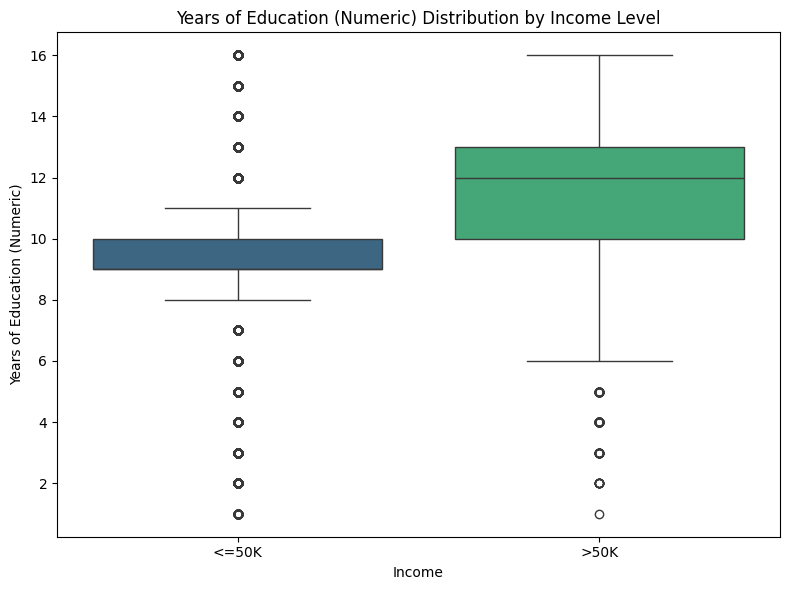

In [163]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='income', y='education-num', hue='income', palette='viridis', legend=False)
plt.title('Years of Education (Numeric) Distribution by Income Level')
plt.xlabel('Income')
plt.ylabel('Years of Education (Numeric)')
plt.tight_layout()
plt.show()

### 2. Relationship
This one is the second most impactful feature according to our correlation. Our `countplot` for 'Income Distribution by Relationship Status' really shows it well. You'll notice that categories like 'Husband' often have a much higher proportion of people earning more than 50K. It might be because married individuals, especially those identifying as 'Husband' or 'Wife', are often in more stable life situations, or perhaps they're older and have more established careers. Or maybe it's the combined household income effect! It's a pretty strong indicator, for sure.

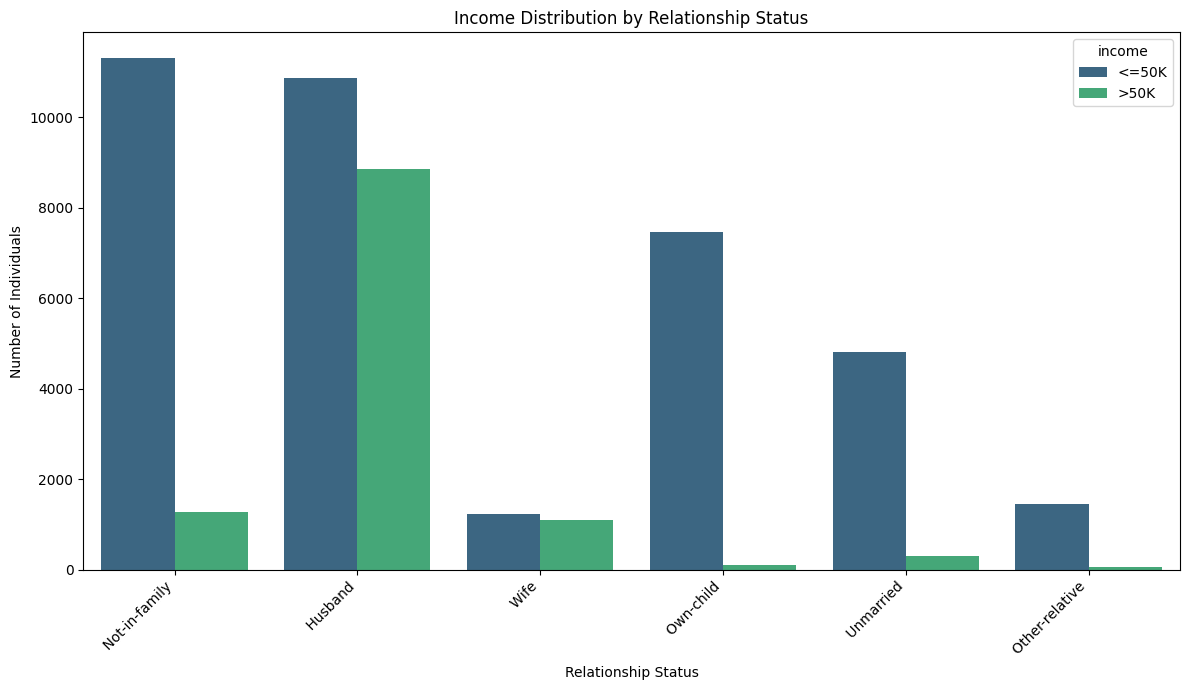

In [165]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='relationship', hue='income', palette='viridis')
plt.title('Income Distribution by Relationship Status')
plt.xlabel('Relationship Status')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3. Age
Coming in third is `age`! If you look at the boxplot for 'Age Distribution by Income Level', you can see that older age groups tend to have a higher median income, especially for the '>50K' bracket. This is pretty intuitive, right? As people get older, they usually gain more experience, climb the career ladder, and their salaries naturally increase. It's all about that career progression and the wisdom that comes with years on the job.

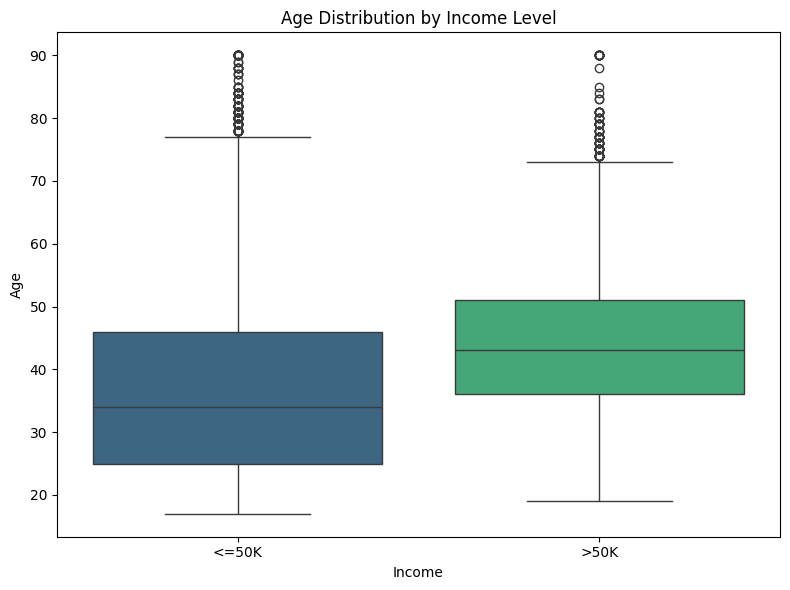

In [166]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='income', y='age', hue='income', palette='viridis', legend=False)
plt.title('Age Distribution by Income Level')
plt.xlabel('Income')
plt.ylabel('Age')
plt.tight_layout()
plt.show()